In [14]:
#1
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
from nltk.probability import FreqDist

packages = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "averaged_perceptron_tagger",
    "wordnet",
    "omw-1.4",
    "maxent_ne_chunker",
    "words"
]

for p in packages:
    try:
        nltk.data.find(p)
    except:
        nltk.download(p)

#Load the dataset
df = pd.read_excel("hotel_customer_reviews.xlsx")

#Tokenize the reviews into words
tokens_list = []

for review in df["review_text"]:
    tokens = word_tokenize(review)
    tokens_list.append(tokens)

df["tokens"] = tokens_list

# Steps 2, 4, 5: Clean + normalize + remove stopwords + remove punctuation
cleaned_list = []

for token_list in df["tokens"]:
    clean_tokens = []
    for w in token_list:
        w_lower = w.lower()
        if (w_lower not in stop_words or w_lower == "not") and w not in punct:
            clean_tokens.append(w_lower)
    cleaned_list.append(clean_tokens)

df["cleaned_tokens"] = cleaned_list

#The frequency of the most common words
all_words = [word for tokens in df["cleaned_tokens"] for word in tokens]
fdist = FreqDist(all_words)

print("Most common words:\n", fdist.most_common(10))

#Create a new column showing the number of words in each cleaned review
df["review_length"] = df["cleaned_tokens"].apply(len)

#Create a simple new column showing Positive, Negative, or Neutral
positive_words = {
    "excellent","clean","friendly","good","amazing","nice",
    "best","comfortable","quiet","helpful","very"
}

negative_words = {
    "dirty","slow","terrible","noisy","rude",
    "uncomfortable","bad","poor","small"
}

def label_sentiment(tokens):
    pos = 0
    neg = 0
    
    for i in range(len(tokens)):
        w = tokens[i]

        if w == "not" and i+1 < len(tokens):
            next_word = tokens[i+1]
            if next_word in positive_words:
                neg += 1
                continue
            if next_word in negative_words:
                pos += 1
                continue

        if w in positive_words:
            pos += 1
        if w in negative_words:
            neg += 1

    if pos > neg:
        return "Positive"
    elif neg > pos:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["cleaned_tokens"].apply(label_sentiment)

df.head(10)

Most common words:
 [('room', 7), ('clean', 4), ('service', 4), ('excellent', 2), ('staff', 2), ('good', 2), ('comfortable', 2), ('bed', 2), ('nice', 2), ('breakfast', 2)]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\h\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\h\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\h\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\h\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\h\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\h\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading pac

,review_id,guest_name,hotel_city,room_type,rating,review_text,tokens,cleaned_tokens,review_length,sentiment_label
0,201,Ali,Toronto,Single,5,"Excellent room, very clean, and friendly staff.","[Excellent, room, ,, very, clean, ,, and, frie...","[excellent, room, clean, friendly, staff]",5,Positive
1,202,Sara,Ottawa,Double,2,The room was dirty and the service was slow.,"[The, room, was, dirty, and, the, service, was...","[room, dirty, service, slow]",4,Negative
2,203,John,Vaughan,Suite,4,"Good location, comfortable bed, and nice break...","[Good, location, ,, comfortable, bed, ,, and, ...","[good, location, comfortable, bed, nice, break...",6,Positive
3,204,Mina,Markham,Single,3,The stay was okay but the room was too small.,"[The, stay, was, okay, but, the, room, was, to...","[stay, okay, room, small]",4,Negative
4,205,David,Toronto,Double,1,"Terrible experience, noisy room, and rude staff.","[Terrible, experience, ,, noisy, room, ,, and,...","[terrible, experience, noisy, room, rude, staff]",6,Negative
5,206,Neda,Ottawa,Suite,5,"Amazing hotel, clean facilities, and fast chec...","[Amazing, hotel, ,, clean, facilities, ,, and,...","[amazing, hotel, clean, facilities, fast, chec...",6,Positive
6,207,Emma,Vaughan,Single,4,Very nice service and comfortable environment.,"[Very, nice, service, and, comfortable, enviro...","[nice, service, comfortable, environment]",4,Positive
7,208,Reza,Toronto,Double,2,The bathroom was not clean and the bed was unc...,"[The, bathroom, was, not, clean, and, the, bed...","[bathroom, not, clean, bed, uncomfortable]",5,Negative
8,209,Sophia,Markham,Suite,5,"Best hotel experience, excellent breakfast and...","[Best, hotel, experience, ,, excellent, breakf...","[best, hotel, experience, excellent, breakfast...",7,Positive
9,210,Omid,Ottawa,Single,3,"Average stay, nothing special but acceptable s...","[Average, stay, ,, nothing, special, but, acce...","[average, stay, nothing, special, acceptable, ...",6,Neutral



Nodes: ['Branch_Toronto', 'Branch_Ottawa', 'Branch_Montreal', 'Branch_Calgary', 'Branch_Edmonton', 'Branch_Winnipeg', 'Branch_Halifax', 'Branch_Regina', 'Branch_Saskatoon', 'Branch_Victoria', 'Branch_Kelowna', 'Branch_Vancouver']

Edges: [('Branch_Toronto', 'Branch_Ottawa', {'weight': 12}), ('Branch_Toronto', 'Branch_Montreal', {'weight': 8}), ('Branch_Ottawa', 'Branch_Calgary', {'weight': 10}), ('Branch_Ottawa', 'Branch_Edmonton', {'weight': 6}), ('Branch_Montreal', 'Branch_Calgary', {'weight': 9}), ('Branch_Montreal', 'Branch_Winnipeg', {'weight': 5}), ('Branch_Calgary', 'Branch_Halifax', {'weight': 11}), ('Branch_Calgary', 'Branch_Regina', {'weight': 4}), ('Branch_Edmonton', 'Branch_Regina', {'weight': 7}), ('Branch_Edmonton', 'Branch_Saskatoon', {'weight': 6}), ('Branch_Winnipeg', 'Branch_Saskatoon', {'weight': 5}), ('Branch_Halifax', 'Branch_Victoria', {'weight': 8}), ('Branch_Halifax', 'Branch_Kelowna', {'weight': 3}), ('Branch_Regina', 'Branch_Vancouver', {'weight': 7}), ('Bran

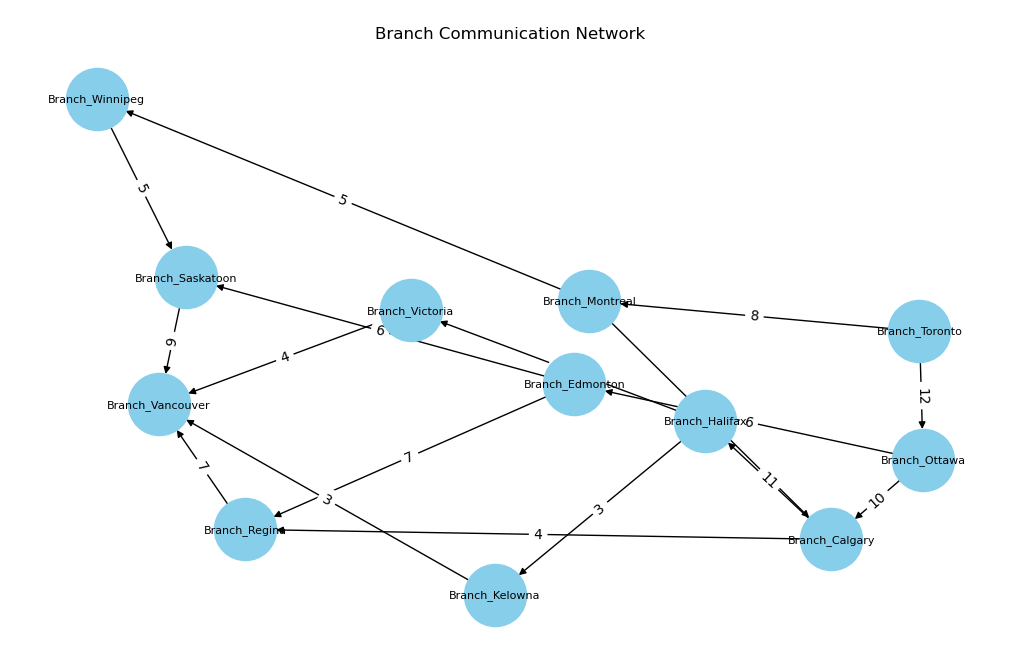

branch_network.html


In [37]:
#2
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

#Load the dataset
df = pd.read_excel("branch_communication_network.xlsx")

#Create a directed weighted graph
DG = nx.DiGraph()

for i, row in df.iterrows():
    DG.add_edge(
        row["source_branch"],
        row["target_branch"],
        weight=row["communication_count"]
    )

#List of nodes and edges
print("\nNodes:", list(DG.nodes()))
print("\nEdges:", list(DG.edges(data=True)))

#The total number of nodes and edges in the network
print("\nTotal nodes:", DG.number_of_nodes())
print("\nTotal edges:", DG.number_of_edges())

#The in-degree and out-degree of each branch
print("\nIn-degree:")
for node in DG.nodes():
    print(node, DG.in_degree(node))

print("\nOut-degree:")
for node in DG.nodes():
    print(node, DG.out_degree(node))

#The degree centrality and betweenness centrality of each branch
centrality = nx.degree_centrality(DG)
print("\nDegree Centrality")
for node, value in centrality.items():
    print(node, ":", round(value,3))

betweenness = nx.betweenness_centrality(DG)
print("\nBetweenness Centrality:")
for node, value in betweenness.items():
    print(node, ":", round(value,3))

#Most connected branch
most_connected = max(centrality, key=centrality.get)
print("\nMost connected node:", most_connected)

#Most important bridge branch
most_important_bridge = max(betweenness, key=centrality.get)
print("\nMost important bridge node:", most_important_bridge)

#The shortest path from Branch_Toronto to Branch_Vancouver
shortest_path = nx.shortest_path(DG, 
                        source="Branch_Toronto", 
                        target="Branch_Vancouver", 
                        weight="weight")
print("\nShortest path Toronto → Vancouver:")
print(shortest_path)

#A basic network visualization
plt.figure(figsize=(10,6))
pos = nx.spring_layout(DG, seed=42)

nx.draw(
    DG,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=2000,
    arrows=True,
    font_size=8
)

edge_labels = nx.get_edge_attributes(DG, "weight")
nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_labels)

plt.title("\nBranch Communication Network")
plt.show()

#Interactive visualization
net = Network(
    height="700px",
    width="100%",
    directed=True,
    notebook=True,
)

for node in DG.nodes():
    net.add_node(
        node,
        label=node,
        size=10 + centrality[node] * 50,
        color="lightgreen"
    )

for source, target, data in DG.edges(data=True):
    net.add_edge(
        source,
        target,
        value=data["weight"],
        title=f"Comm: {data['weight']}"
    )

net.show("branch_network.html")

In [54]:
#3
import pandas as pd

#Structure, columns, and shapes of all datasets.
customers = pd.read_excel("customer_feedback_data.xlsx", sheet_name="customers")
feedback = pd.read_excel("customer_feedback_data.xlsx", sheet_name="feedback")
branches = pd.read_excel("customer_feedback_data.xlsx", sheet_name="branches")

print("Customers DataFrame:")
display(customers)
print("Customers columns:", customers.columns.tolist())
print("Customers shape:", customers.shape)

print("\nFeedback DataFrame:")
display(feedback)
print("Feedback columns:", feedback.columns.tolist())
print("Feedback shape:", feedback.shape)

print("\nBranches DataFrame:")
display(branches)
print("Branches columns:", branches.columns.tolist())
print("Branches shape:", branches.shape)

#The common key columns for combining
print("\nCustomers columns:", customers.columns.tolist())
print("Feedback columns:", feedback.columns.tolist())
print("Branches columns:", branches.columns.tolist())

print("\nCommon key between customers and feedback: customer_id")
print("Common key between feedback and branches: branch_id\n")

#Merge the datasets into one final table
customers_feedback = pd.merge(customers, feedback, on="customer_id", how="left")
final = pd.merge(customers_feedback, branches, on="branch_id", how="left")
display(final)

#Clean the review text
final["clean_review"] = final["review_text"].str.lower().str.strip()

#Create a new column showing the length of each review
final["review_length"] = final["clean_review"].str.len()

#Check whether each review contains words
final["has_delivery"] = final["clean_review"].str.contains("delivery", case=False, na=False)
final["has_price"] = final["clean_review"].str.contains("price", case=False, na=False)
final["has_service"] = final["clean_review"].str.contains("service", case=False, na=False)

print("\nKeyword Detection Columns:")
display(final[[
    "review_id",
    "clean_review",
    "has_delivery",
    "has_price",
    "has_service"
]])

#Count how many reviews mention each keyword
print("\nKeyword Mention Counts:")
print("delivery:", final["has_delivery"].sum())
print("price:", final["has_price"].sum())
print("service:", final["has_service"].sum())

#The average rating by branch city
avg_rating_city = final.groupby("branch_city").agg({
    "rating":"mean"
})

print("\nAverage Rating by Branch city")
display(avg_rating_city)

#Create a pivot table
pivot = final.pivot_table(
    values="review_id",
    index="branch_name",
    columns="rating",
    aggfunc="count",
    fill_value=0
)

print("\nThe number of reviews by branch and rating.")
display(pivot)

#Identify missing values and unmatched records
merged_indicator = pd.merge(
    customers,
    feedback,
    on="customer_id",
    how="outer",
    indicator=True
)
print("\nOuter Merge with Indicator")
display(merged_indicator)

missing_values = merged_indicator.isna().sum()
print("\nMissing Values After Merge")
display(missing_values)

#A short interpretation of the business insights
print("\nBusiness Insights:")
print(f"""
- Among these branches, the Vaughan branch performs best with the highest average rating of 4.5/5.0 and gets good reviews,
such as excellent price and excellent support.
- On the other hand, the Oshawa branch needs urgent service improvement since it has the lowest average rating of 2.5 and gets complaints,
including poor service and rude staff.
- Delivery is a major theme that is mentioned in 4 reviews. Some praise fast delivery, others complain about delays.
Therefore, delivery operations should be standardized across branches.
- Price appears in 3 reviews, mostly positive.
- Ajax branch has the worst single review, rating = 1. It mentions “terrible experience and bad delivery”,
indicating a potential operational failure at that branch.
- Markham branch has no feedback. It shows that the company should investigate visibility or customer engagement
because a lack of customer reviews may indicate low traffic.
"""
     )




Customers DataFrame:


,customer_id,customer_name,city
0,201,Ava,Toronto
1,202,Noah,Oshawa
2,203,Liam,Markham
3,204,Emma,Toronto
4,205,Mason,Vaughan
5,206,Sophia,Oshawa
6,207,Ethan,Ajax


Customers columns: ['customer_id', 'customer_name', 'city']
Customers shape: (7, 3)

Feedback DataFrame:


,review_id,customer_id,branch_id,rating,review_text
0,5001,201,B01,5,Great delivery service and fast response
1,5002,202,B02,4,Price was reasonable and service was good
2,5003,203,B01,3,Delivery was late but product quality was fine
3,5004,204,B03,2,Very poor service and rude staff
4,5005,205,B02,5,Excellent price and excellent support
5,5006,208,B01,4,Fast delivery and good communication
6,5007,206,B03,3,Average service but acceptable price
7,5008,207,B04,1,Terrible experience and bad delivery


Feedback columns: ['review_id', 'customer_id', 'branch_id', 'rating', 'review_text']
Feedback shape: (8, 5)

Branches DataFrame:


...


Outer Merge with Indicator


,customer_id,customer_name,city,review_id,branch_id,rating,review_text,_merge
0,201,Ava,Toronto,5001,B01,5,Great delivery service and fast response,both
1,202,Noah,Oshawa,5002,B02,4,Price was reasonable and service was good,both
2,203,Liam,Markham,5003,B01,3,Delivery was late but product quality was fine,both
3,204,Emma,Toronto,5004,B03,2,Very poor service and rude staff,both
4,205,Mason,Vaughan,5005,B02,5,Excellent price and excellent support,both
5,206,Sophia,Oshawa,5007,B03,3,Average service but acceptable price,both
6,207,Ethan,Ajax,5008,B04,1,Terrible experience and bad delivery,both
7,208,NaN,NaN,5006,B01,4,Fast delivery and good communication,right_only



Missing Values After Merge


customer_id      0
customer_name    1
city             1
review_id        0
branch_id        0
rating           0
review_text      0
_merge           0
dtype: int64


Business Insights:

- Among these branches, the Vaughan branch performs best with the highest average rating of 4.5/5.0 and gets good reviews,
such as excellent price and excellent support.
- On the other hand, the Oshawa branch needs urgent service improvement since it has the lowest average rating of 2.5 and gets complaints,
including poor service and rude staff.
- Delivery is a major theme that is mentioned in 4 reviews. Some praise fast delivery, others complain about delays.
Therefore, delivery operations should be standardized across branches.
- Price appears in 3 reviews, mostly positive.
- Ajax branch has the worst single review, rating = 1. It mentions “terrible experience and bad delivery”,
indicating a potential operational failure at that branch.
- Markham branch has no feedback. It shows that the company should investigate visibility or customer engagement
because a lack of customer reviews may indicate low traffic.

